In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Pipeline Overview
# ─────────────────────────────────────────────────────────────────
"""
NB1: DEAP EEG Preprocessing Pipeline
=====================================
PURPOSE  : Produce a clean, reusable, task-agnostic feature dataset.
OUTPUT   : Feature matrix + raw labels + subject IDs + train/test splits.
CONSUMES : NB2 (Emotion Recognition) and NB3 (Stress Recognition).

DEAP Dataset Facts:
  - 32 subjects, 40 trials each → 1280 samples total
  - 40 channels: 32 EEG + 8 peripheral (EOG, EMG, GSR, BVP, Resp, Temp)
  - 8064 samples per trial at 128 Hz = 63 seconds (3s baseline + 60s stimulus)
  - 4 labels per trial: Valence, Arousal, Dominance, Liking (scale 1–9)

Critical Design Rules (enforced throughout):
  [R1] NO task-specific labels — raw continuous labels only
  [R2] Scaler fit ONLY on training subjects — never on full dataset
  [R3] Subject IDs preserved for LeaveOneSubjectOut CV downstream
  [R4] EEG channels (0-31) and peripheral channels (32-39) treated separately
  [R5] Baseline (first 3 s = 384 samples) removed before feature extraction
  [R6] All outputs persisted to disk — RAM is not a pipeline output
"""
print("=" * 65)
print("  NB1: DEAP Signal Processing Pipeline")
print("  Task-agnostic | Feeds NB2 (Emotion) and NB3 (Stress)")
print("=" * 65)

  NB1: DEAP Signal Processing Pipeline
  Task-agnostic | Feeds NB2 (Emotion) and NB3 (Stress)


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Install Dependencies
# ─────────────────────────────────────────────────────────────────
!pip install -q scipy scikit-learn pandas numpy matplotlib seaborn pyarrow

import importlib, subprocess, sys

required = ['scipy', 'sklearn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'pyarrow']
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  ✗ {pkg} — FAILED TO INSTALL")

  ✓ scipy
  ✓ sklearn
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ seaborn
  ✓ pyarrow


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Imports and Global Seed
# ─────────────────────────────────────────────────────────────────
import os
import sys
import pickle
import random
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.signal import welch
from scipy.stats import skew, kurtosis, pearsonr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── Global random seed (R: reproducibility) ──────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Plot style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 4)})

print("Imports complete. Random seed:", RANDOM_SEED)
print("NumPy:", np.__version__, "| Pandas:", pd.__version__)

Imports complete. Random seed: 42
NumPy: 2.0.2 | Pandas: 2.2.2


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Centralized Configuration
# ─────────────────────────────────────────────────────────────────
# All pipeline parameters in one place — change here, not scattered
# through the notebook.

CONFIG = {
    # ── Dataset ───────────────────────────────────────────────────
    'n_subjects':          32,
    'n_trials':            40,
    'n_channels':          40,
    'n_eeg_channels':      32,
    'n_periph_channels':    8,
    'fs':                 128,      # sampling frequency (Hz)
    'total_samples':     8064,      # 128 Hz × 63 s
    'baseline_seconds':     3,
    'baseline_samples':   384,      # 3 × 128  — REMOVED before extraction
    'stimulus_samples':  7680,      # 60 × 128 — used for features

    # ── Frequency bands (EEG only) ────────────────────────────────
    'freq_bands': {
        'delta': (1,  4),
        'theta': (4,  8),
        'alpha': (8,  13),
        'beta':  (13, 30),
        'gamma': (30, 50),
    },

    # ── Artifact detection thresholds ────────────────────────────
    'artifact_amplitude_uv': 100,   # peak abs amplitude per channel
    'artifact_flat_std':     0.1,   # std threshold for flat channels
    'artifact_max_bad_ch':    4,    # trials with >4 bad EEG ch flagged

    # ── Train / test split (subject-level — prevents leakage) ─────
    'train_ratio': 0.8,             # 26 train subjects, 6 test subjects

    # ── Scaling ───────────────────────────────────────────────────
    # Scaler is fit on training subjects ONLY (see Cell 18)
    'scaler': 'standard',

    # ── PCA ───────────────────────────────────────────────────────
    'pca_enabled':            True,
    'pca_variance_target':    0.95, # retain components covering 95% variance

    # ── Paths ─────────────────────────────────────────────────────
    'data_path':   '/content/drive/MyDrive/MiniProj/deapppd/deap-dataset/data_preprocessed_python/',
    'output_dir':  '/content/drive/MyDrive/MiniProj/deap_processed_v1/',

    # ── Reproducibility ───────────────────────────────────────────
    'random_seed': RANDOM_SEED,
    'pipeline_version': '1.0',
    'created_at': datetime.now().isoformat(),
}

# ── Channel name registry ─────────────────────────────────────────
EEG_CHANNEL_NAMES = [
    'Fp1','AF3','F3','F7','FC5','FC1','C3','T7',
    'CP5','CP1','P3','P7','PO3','O1','Oz','Pz',
    'P4','P8','PO4','O2','T8','CP6','CP2','C4',
    'FC6','FC2','F4','F8','AF4','Fp2','Fz','Cz',
]
PERIPH_CHANNEL_NAMES = ['hEOG','vEOG','zEMG','tEMG','GSR','Respiration','BVP','Temp']
ALL_CHANNEL_NAMES   = EEG_CHANNEL_NAMES + PERIPH_CHANNEL_NAMES
LABEL_NAMES         = ['valence','arousal','dominance','liking']

assert len(EEG_CHANNEL_NAMES)   == CONFIG['n_eeg_channels']
assert len(PERIPH_CHANNEL_NAMES)== CONFIG['n_periph_channels']
assert len(ALL_CHANNEL_NAMES)   == CONFIG['n_channels']

print("Configuration validated.")
print(f"  Subjects     : {CONFIG['n_subjects']}")
print(f"  Trials each  : {CONFIG['n_trials']}  →  {CONFIG['n_subjects']*CONFIG['n_trials']} total samples")
print(f"  Channels     : {CONFIG['n_eeg_channels']} EEG + {CONFIG['n_periph_channels']} peripheral")
print(f"  Sampling rate: {CONFIG['fs']} Hz")
print(f"  Baseline     : {CONFIG['baseline_samples']} samples ({CONFIG['baseline_seconds']} s) — will be REMOVED")
print(f"  Stimulus     : {CONFIG['stimulus_samples']} samples ({CONFIG['stimulus_samples']//CONFIG['fs']} s)")
print(f"  Output dir   : {CONFIG['output_dir']}")

Configuration validated.
  Subjects     : 32
  Trials each  : 40  →  1280 total samples
  Channels     : 32 EEG + 8 peripheral
  Sampling rate: 128 Hz
  Baseline     : 384 samples (3 s) — will be REMOVED
  Stimulus     : 7680 samples (60 s)
  Output dir   : /content/drive/MyDrive/MiniProj/deap_processed_v1/


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Mount Google Drive
# ─────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Verify data path exists
data_path = Path(CONFIG['data_path'])
if not data_path.exists():
    raise FileNotFoundError(
        f"\n[ERROR] Data directory not found: {data_path}\n"
        f"Check CONFIG['data_path'] and ensure Drive is mounted correctly."
    )

# Count available files
dat_files = sorted(data_path.glob('s*.dat'))
print(f"Data directory found: {data_path}")
print(f"Subject files found : {len(dat_files)} / {CONFIG['n_subjects']}")
if len(dat_files) < CONFIG['n_subjects']:
    print(f"[WARNING] Expected {CONFIG['n_subjects']} files, found {len(dat_files)}.")
else:
    print("All subject files present.")

# Create output directory
out_dir = Path(CONFIG['output_dir'])
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory ready: {out_dir}")

Mounted at /content/drive
Data directory found: /content/drive/MyDrive/MiniProj/deapppd/deap-dataset/data_preprocessed_python
Subject files found : 32 / 32
All subject files present.
Output directory ready: /content/drive/MyDrive/MiniProj/deap_processed_v1


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Data Loading Functions
# ─────────────────────────────────────────────────────────────────

def load_subject(filepath: Path) -> dict:
    """
    Load a single DEAP subject file.

    Returns
    -------
    dict with keys:
        'data'   : np.ndarray  shape (40, 40, 8064)   float32
                    axis 0 = trials, axis 1 = channels, axis 2 = time
        'labels' : np.ndarray  shape (40, 4)           float32
                    columns = [valence, arousal, dominance, liking]
        'subject_id' : int (1-indexed, matching filename)
        'filename'   : str
    """
    with open(filepath, 'rb') as f:
        raw = pickle.load(f, encoding='latin1')

    data   = raw['data'].astype(np.float32)    # (40, 40, 8064)
    labels = raw['labels'].astype(np.float32)  # (40, 4)

    # Validate DEAP-expected shape
    expected_data_shape = (
        CONFIG['n_trials'],
        CONFIG['n_channels'],
        CONFIG['total_samples'],
    )
    expected_label_shape = (CONFIG['n_trials'], len(LABEL_NAMES))

    if data.shape != expected_data_shape:
        raise ValueError(
            f"{filepath.name}: data shape {data.shape} != expected {expected_data_shape}"
        )
    if labels.shape != expected_label_shape:
        raise ValueError(
            f"{filepath.name}: label shape {labels.shape} != expected {expected_label_shape}"
        )

    # Parse subject ID from filename (s01.dat → 1, s32.dat → 32)
    subject_id = int(filepath.stem[1:])

    return {
        'data':       data,
        'labels':     labels,
        'subject_id': subject_id,
        'filename':   filepath.name,
    }


def validate_label_range(labels: np.ndarray, subject_id: int) -> None:
    """Warn if any label value falls outside the DEAP 1–9 scale."""
    for col_idx, col_name in enumerate(LABEL_NAMES):
        col = labels[:, col_idx]
        lo, hi = col.min(), col.max()
        if lo < 1.0 or hi > 9.0:
            print(f"  [WARN] Subject {subject_id:02d} | {col_name}: range [{lo:.2f}, {hi:.2f}] outside [1, 9]")


print("Loading functions defined.")
print("  load_subject()       — loads and validates a single .dat file")
print("  validate_label_range() — checks label values stay within [1, 9]")

Loading functions defined.
  load_subject()       — loads and validates a single .dat file
  validate_label_range() — checks label values stay within [1, 9]


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — Load All Subjects
# ─────────────────────────────────────────────────────────────────

raw_data   = []   # list of (40, 40, 8064) arrays
raw_labels = []   # list of (40, 4) arrays
subject_ids_per_trial = []   # [1,1,...,1, 2,2,...,2, ..., 32,32,...,32]
load_errors = []

print("Loading subjects...")
for filepath in sorted(data_path.glob('s*.dat')):
    try:
        subject = load_subject(filepath)
        validate_label_range(subject['labels'], subject['subject_id'])

        raw_data.append(subject['data'])    # (40, 40, 8064)
        raw_labels.append(subject['labels'])  # (40, 4)

        # Each subject contributes 40 trial rows
        subject_ids_per_trial.extend([subject['subject_id']] * CONFIG['n_trials'])

        print(f"  ✓ Subject {subject['subject_id']:02d}  —  data {subject['data'].shape}, labels {subject['labels'].shape}")

    except Exception as e:
        load_errors.append((filepath.name, str(e)))
        print(f"  ✗ {filepath.name}  —  ERROR: {e}")

if load_errors:
    print(f"\n[WARNING] {len(load_errors)} file(s) failed to load:")
    for fname, err in load_errors:
        print(f"  {fname}: {err}")

# ── Concatenate into unified arrays ──────────────────────────────
# X : (1280, 40, 8064)  — all subjects × trials
# y : (1280, 4)         — continuous labels, no discretization [R1]
X_raw = np.concatenate(raw_data,   axis=0).astype(np.float32)   # (1280, 40, 8064)
y_raw = np.concatenate(raw_labels, axis=0).astype(np.float32)   # (1280, 4)
subject_ids = np.array(subject_ids_per_trial, dtype=np.int32)   # (1280,)

print(f"\nDataset assembled:")
print(f"  X_raw shape     : {X_raw.shape}   (samples, channels, timepoints)")
print(f"  y_raw shape     : {y_raw.shape}     (samples, labels)")
print(f"  subject_ids     : {subject_ids.shape}  — unique subjects: {np.unique(subject_ids)}")
print(f"  Memory (X_raw)  : {X_raw.nbytes / 1e9:.2f} GB")

Loading subjects...
  [WARN] Subject 01 | valence: range [0.00, 8.27] outside [1, 9]
  ✓ Subject 01  —  data (40, 40, 8064), labels (40, 4)
  [WARN] Subject 02 | valence: range [0.00, 9.00] outside [1, 9]
  [WARN] Subject 02 | arousal: range [0.00, 9.00] outside [1, 9]
  ✓ Subject 02  —  data (40, 40, 8064), labels (40, 4)
  ✓ Subject 03  —  data (40, 40, 8064), labels (40, 4)
  [WARN] Subject 04 | valence: range [0.05, 6.10] outside [1, 9]
  [WARN] Subject 04 | arousal: range [0.90, 6.96] outside [1, 9]
  ✓ Subject 04  —  data (40, 40, 8064), labels (40, 4)
  [WARN] Subject 05 | valence: range [0.00, 8.05] outside [1, 9]
  [WARN] Subject 05 | arousal: range [0.00, 9.00] outside [1, 9]
  ✓ Subject 05  —  data (40, 40, 8064), labels (40, 4)
  [WARN] Subject 06 | valence: range [0.74, 8.19] outside [1, 9]
  [WARN] Subject 06 | arousal: range [0.73, 5.74] outside [1, 9]
  ✓ Subject 06  —  data (40, 40, 8064), labels (40, 4)
  [WARN] Subject 07 | valence: range [0.90, 8.10] outside [1, 9]


In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 — Dataset Validation
# ─────────────────────────────────────────────────────────────────

print("=" * 55)
print("DATASET VALIDATION")
print("=" * 55)

# ── Shape checks ─────────────────────────────────────────────────
n_samples = CONFIG['n_subjects'] * CONFIG['n_trials']
assert X_raw.shape == (n_samples, CONFIG['n_channels'], CONFIG['total_samples']), \
    f"Shape mismatch: got {X_raw.shape}"
assert y_raw.shape == (n_samples, len(LABEL_NAMES)), \
    f"Label shape mismatch: got {y_raw.shape}"
assert len(subject_ids) == n_samples
assert np.all(np.isfinite(X_raw)), "X_raw contains NaN or Inf values"
assert np.all(np.isfinite(y_raw)), "y_raw contains NaN or Inf values"
print("✓ Shapes correct and no NaN/Inf in arrays")

# ── Subject ID distribution ───────────────────────────────────────
unique_subjects, counts = np.unique(subject_ids, return_counts=True)
assert np.all(counts == CONFIG['n_trials']), "Unequal trial counts across subjects"
print(f"✓ {len(unique_subjects)} subjects × {CONFIG['n_trials']} trials = {n_samples} samples")

# ── Label range ───────────────────────────────────────────────────
print("\nLabel statistics (raw continuous, scale 1–9):")
df_labels = pd.DataFrame(y_raw, columns=LABEL_NAMES)
print(df_labels.describe().round(3).to_string())

out_of_range = ((y_raw < 1.0) | (y_raw > 9.0)).any(axis=1).sum()
if out_of_range > 0:
    print(f"\n[WARNING] {out_of_range} samples have labels outside [1, 9]")
else:
    print("\n✓ All label values within expected [1.0, 9.0] range")

# ── Signal range summary (EEG channels only) ─────────────────────
eeg_signal = X_raw[:, :32, 384:]   # remove baseline for inspection
print(f"\nEEG signal range (post-baseline removal):")
print(f"  Global min : {eeg_signal.min():.2f} µV")
print(f"  Global max : {eeg_signal.max():.2f} µV")
print(f"  Global mean: {eeg_signal.mean():.4f} µV")
print(f"  Global std : {eeg_signal.std():.2f} µV")

print("\n✓ Validation complete.")

DATASET VALIDATION
✓ Shapes correct and no NaN/Inf in arrays
✓ 32 subjects × 40 trials = 1280 samples

Label statistics (raw continuous, scale 1–9):
        valence   arousal  dominance    liking
count  1280.000  1280.000   1280.000  1280.000
mean      3.465     3.730      5.383     5.518
std       2.010     1.980      2.096     2.283
min       0.000     0.000      1.000     1.000
25%       1.950     2.060      3.933     3.960
50%       3.080     3.315      5.240     6.050
75%       4.950     4.990      7.040     7.090
max       9.000     9.000      9.000     9.000

[WARNING] 132 samples have labels outside [1, 9]

EEG signal range (post-baseline removal):
  Global min : -2656.43 µV
  Global max : 2765.85 µV
  Global mean: -0.0000 µV
  Global std : 32.23 µV

✓ Validation complete.


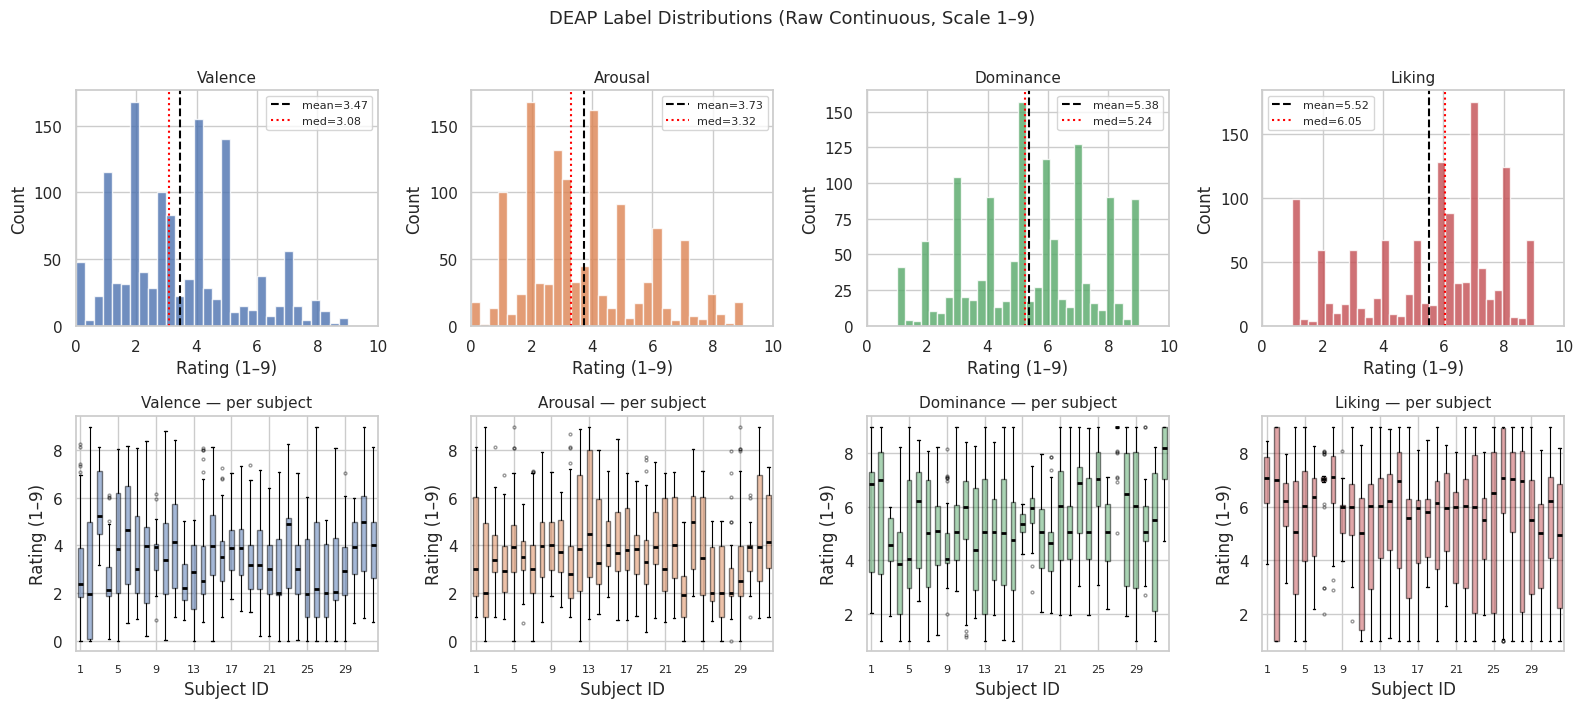

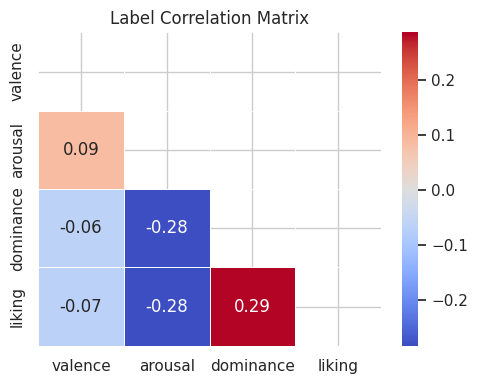

Key observations:
  valence   : mean=3.47  std=2.01  skew=+0.47  [0.0, 9.0]
  arousal   : mean=3.73  std=1.98  skew=+0.57  [0.0, 9.0]
  dominance : mean=5.38  std=2.10  skew=-0.13  [1.0, 9.0]
  liking    : mean=5.52  std=2.28  skew=-0.56  [1.0, 9.0]


In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — EDA: Label Distributions
# ─────────────────────────────────────────────────────────────────
# NOTE: No discretization or threshold-based classification here.
# Labels are explored as continuous variables. Task-specific label
# engineering (emotion quadrants, stress binary) happens in NB2/NB3.

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("DEAP Label Distributions (Raw Continuous, Scale 1–9)", fontsize=13, y=1.01)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── Row 1: Histograms ──────────────────────────────────────────
for i, (name, color) in enumerate(zip(LABEL_NAMES, colors)):
    ax = axes[0, i]
    data_col = y_raw[:, i]
    ax.hist(data_col, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(data_col), color='black', linestyle='--', linewidth=1.5, label=f'mean={np.mean(data_col):.2f}')
    ax.axvline(np.median(data_col), color='red',   linestyle=':',  linewidth=1.5, label=f'med={np.median(data_col):.2f}')
    ax.set_title(name.capitalize(), fontsize=11)
    ax.set_xlabel("Rating (1–9)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 10)

# ── Row 2: Box plots by subject ────────────────────────────────
df_plot = pd.DataFrame(y_raw, columns=LABEL_NAMES)
df_plot['subject_id'] = subject_ids

for i, (name, color) in enumerate(zip(LABEL_NAMES, colors)):
    ax = axes[1, i]
    subj_medians = df_plot.groupby('subject_id')[name].median().values
    ax.boxplot([df_plot[df_plot['subject_id'] == s][name].values
                for s in sorted(df_plot['subject_id'].unique())],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=0.8),
               flierprops=dict(marker='o', markersize=2, alpha=0.4))
    ax.set_title(f"{name.capitalize()} — per subject", fontsize=11)
    ax.set_xlabel("Subject ID")
    ax.set_ylabel("Rating (1–9)")
    ax.set_xticks(range(1, 33, 4))
    ax.set_xticklabels(range(1, 33, 4), fontsize=8)

plt.tight_layout()
plt.savefig(str(out_dir / 'eda_label_distributions.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Correlation matrix ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
corr = df_labels.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title("Label Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir / 'eda_label_correlation.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Key observations:")
for name in LABEL_NAMES:
    col = y_raw[:, LABEL_NAMES.index(name)]
    print(f"  {name:10s}: mean={col.mean():.2f}  std={col.std():.2f}  "
          f"skew={float(skew(col)):+.2f}  "
          f"[{col.min():.1f}, {col.max():.1f}]")

Per-subject label variability (std across 40 trials):
-------------------------------------------------------

[FLAG] Subjects with any label std < 0.5:
            valence  arousal  dominance  liking
subject_id                                     
17            1.418    1.459      0.426   1.743

  Consider reviewing these subjects — low variability means the
  labels may not discriminate emotional states for that subject.


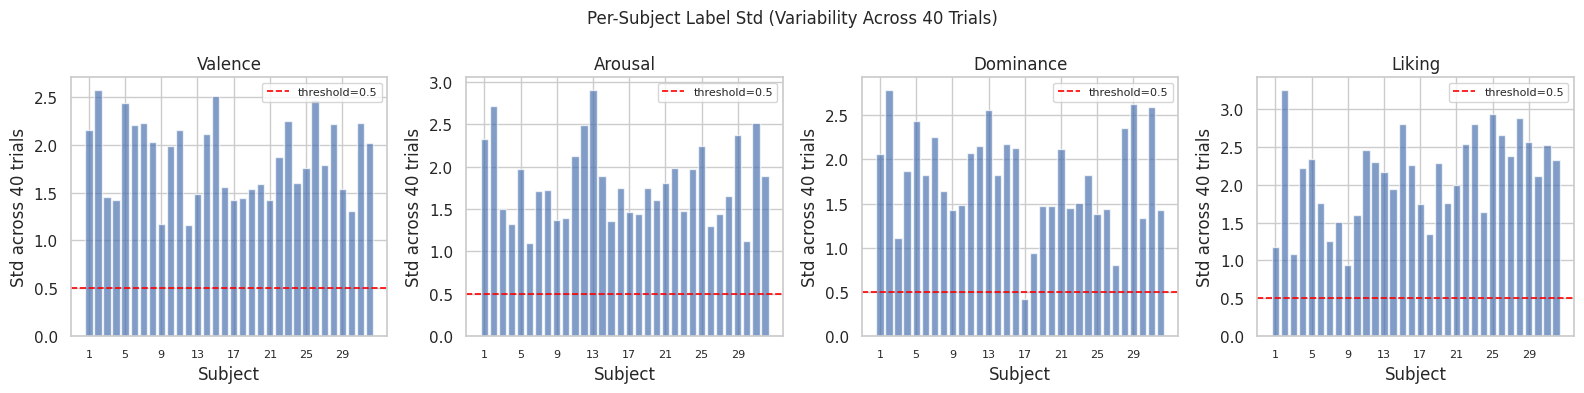


Mean label std across all subjects:
valence      1.847
arousal      1.803
dominance    1.781
liking       2.111


In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 10 — EDA: Per-Subject Variability
# ─────────────────────────────────────────────────────────────────
# Subjects with near-constant label ratings reduce signal quality.
# Flag them here — the researcher decides whether to exclude.

print("Per-subject label variability (std across 40 trials):")
print("-" * 55)

df_subject_stats = {}
for subj in sorted(np.unique(subject_ids)):
    mask = subject_ids == subj
    subj_labels = y_raw[mask]         # (40, 4)
    stds = subj_labels.std(axis=0)    # std across 40 trials per dimension
    df_subject_stats[subj] = stds

df_var = pd.DataFrame(df_subject_stats, index=LABEL_NAMES).T
df_var.index.name = 'subject_id'

# Flag subjects with very low variability (< 0.5 std in any dimension)
LOW_VAR_THRESHOLD = 0.5
low_var_subjects = df_var[df_var.min(axis=1) < LOW_VAR_THRESHOLD]
print(f"\n[FLAG] Subjects with any label std < {LOW_VAR_THRESHOLD}:")
if len(low_var_subjects) > 0:
    print(low_var_subjects.round(3).to_string())
    print("\n  Consider reviewing these subjects — low variability means the")
    print("  labels may not discriminate emotional states for that subject.")
else:
    print("  None — all subjects show reasonable label variability.")

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Per-Subject Label Std (Variability Across 40 Trials)", fontsize=12)
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    vals = df_var[name].values
    bars = ax.bar(np.arange(1, 33), vals, color='#4C72B0', alpha=0.7)
    ax.axhline(LOW_VAR_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
               label=f'threshold={LOW_VAR_THRESHOLD}')
    ax.set_title(name.capitalize())
    ax.set_xlabel("Subject")
    ax.set_ylabel("Std across 40 trials")
    ax.set_xticks(range(1, 33, 4))
    ax.set_xticklabels(range(1, 33, 4), fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(out_dir / 'eda_subject_variability.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"\nMean label std across all subjects:")
print(df_var.mean().round(3).to_string())

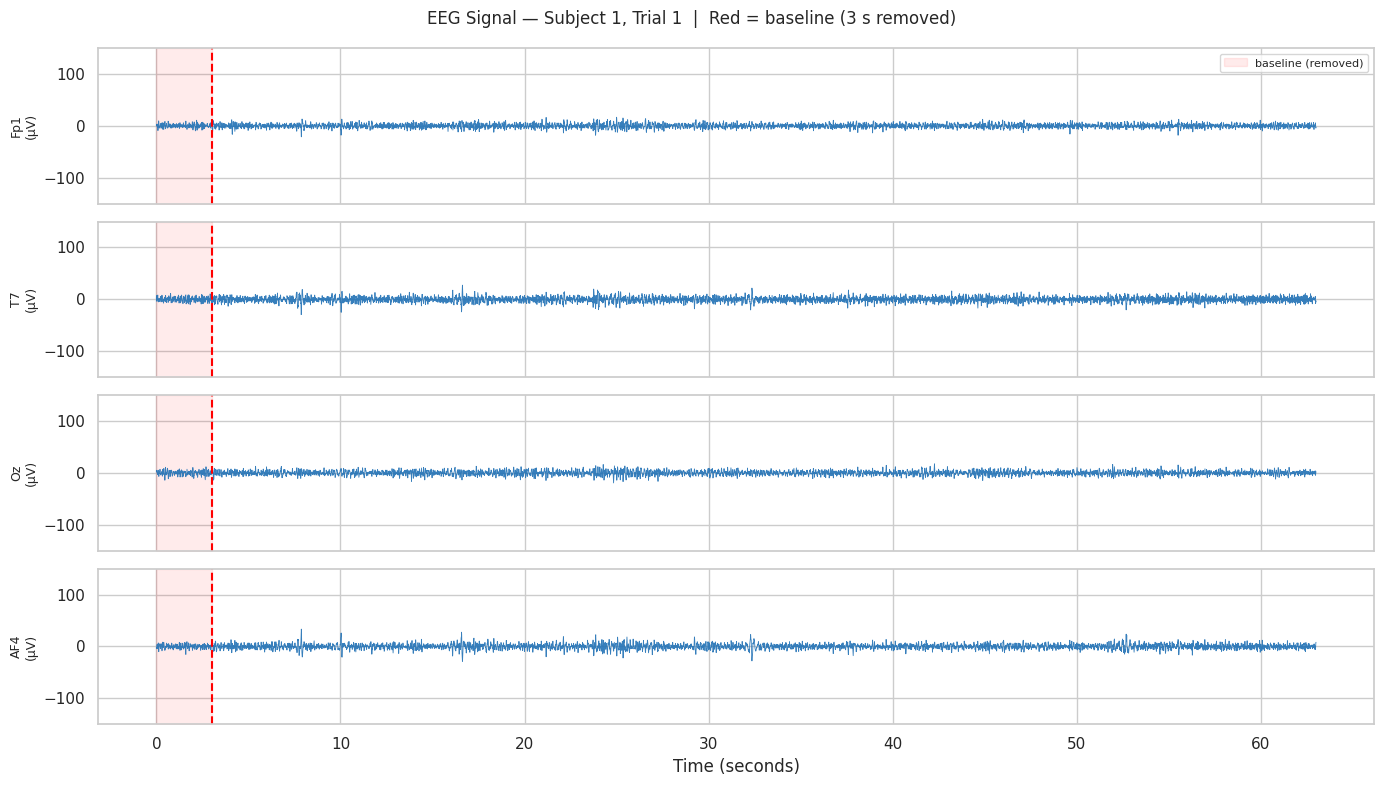

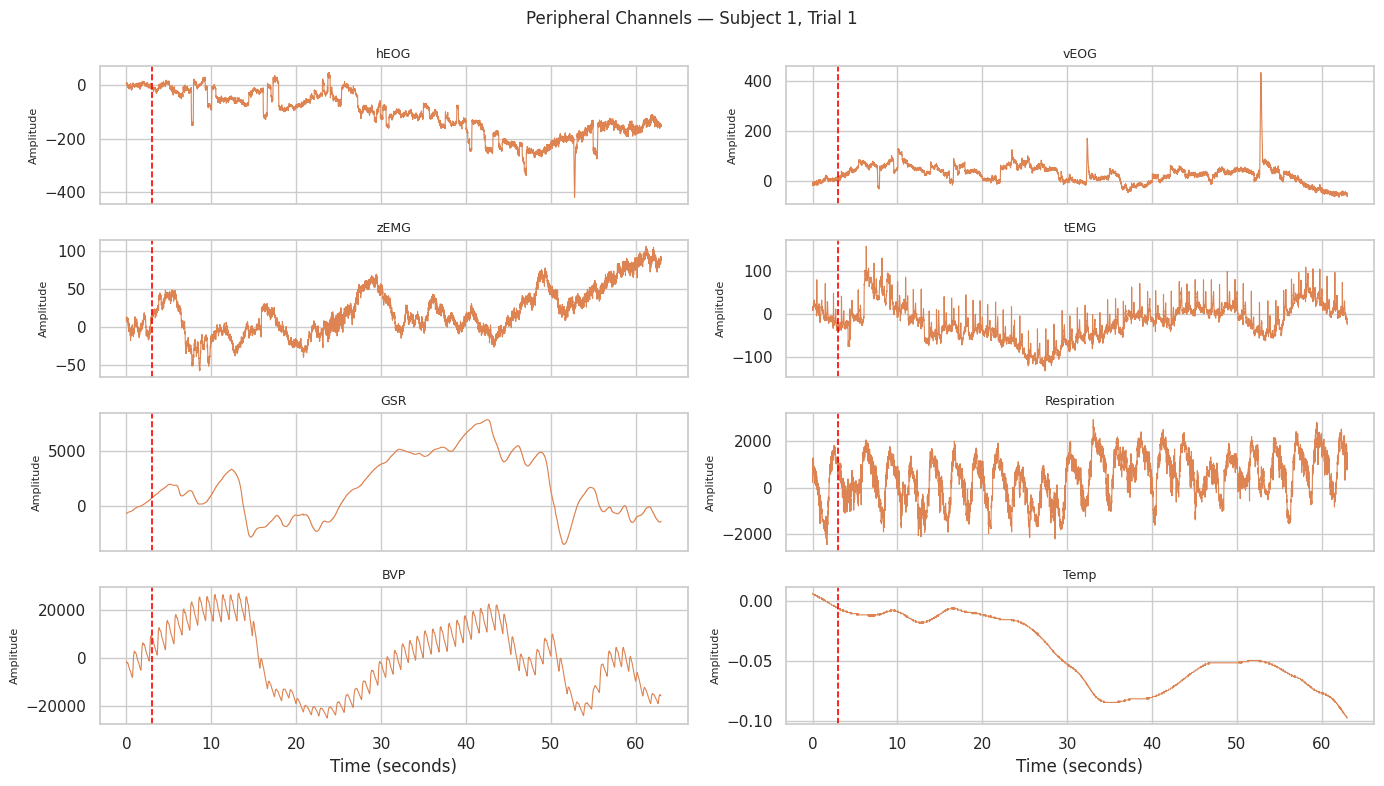

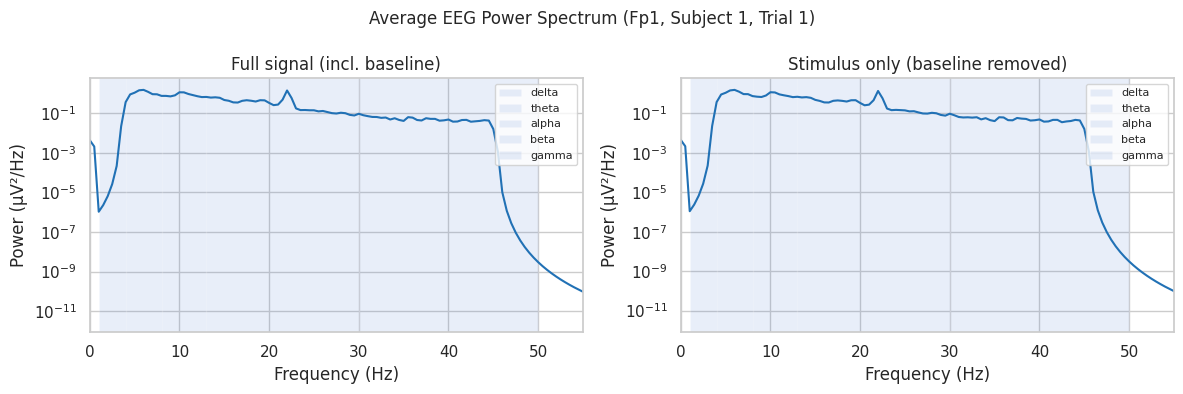

In [11]:
# ─────────────────────────────────────────────────────────────────
# CELL 11 — EDA: Raw Signal Visualization
# ─────────────────────────────────────────────────────────────────
# Show what the raw EEG looks like — baseline period vs stimulus,
# EEG channels vs peripheral channels. This is the part the
# previous notebook completely skipped.

rng_viz = np.random.RandomState(RANDOM_SEED)
sample_subject = 1    # subject index (1-indexed)
sample_trial   = 0    # trial index

# Get this trial's data
subj_mask = subject_ids == sample_subject
trial_data = X_raw[subj_mask][sample_trial]   # (40, 8064)

t = np.arange(CONFIG['total_samples']) / CONFIG['fs']          # time axis in seconds
baseline_end_sec = CONFIG['baseline_seconds']                   # 3.0

# ── Plot 1: 4 EEG channels — baseline vs stimulus ─────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"EEG Signal — Subject {sample_subject}, Trial 1  |  Red = baseline (3 s removed)", fontsize=12)

channels_to_show = [0, 7, 14, 28]   # Fp1, T7, Pz, Fp2 (frontal/temporal/parietal)
for ax, ch_idx in zip(axes, channels_to_show):
    signal = trial_data[ch_idx]
    ax.fill_betweenx([-150, 150], 0, baseline_end_sec,
                     color='red', alpha=0.08, label='baseline (removed)')
    ax.plot(t, signal, linewidth=0.6, color='#2171B5', alpha=0.9)
    ax.axvline(baseline_end_sec, color='red', linewidth=1.5, linestyle='--')
    ax.set_ylabel(f"{EEG_CHANNEL_NAMES[ch_idx]}\n(µV)", fontsize=9)
    ax.set_ylim(-150, 150)
    if ch_idx == channels_to_show[0]:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.savefig(str(out_dir / 'eda_raw_eeg_signal.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Plot 2: Peripheral channels ───────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 8), sharex=True)
fig.suptitle(f"Peripheral Channels — Subject {sample_subject}, Trial 1", fontsize=12)
axes = axes.flatten()
for i, (ax, ch_name) in enumerate(zip(axes, PERIPH_CHANNEL_NAMES)):
    ch_idx = 32 + i
    signal = trial_data[ch_idx]
    ax.plot(t, signal, linewidth=0.8, color='#DD8452')
    ax.axvline(baseline_end_sec, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(ch_name, fontsize=9)
    ax.set_ylabel("Amplitude", fontsize=8)

for ax in axes[-2:]:
    ax.set_xlabel("Time (seconds)")

plt.tight_layout()
plt.savefig(str(out_dir / 'eda_peripheral_signals.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Plot 3: Average power spectrum (pre vs post baseline removal) ─
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Average EEG Power Spectrum (Fp1, Subject 1, Trial 1)", fontsize=12)

signal_full = trial_data[0]                              # full 63 s
signal_stim = trial_data[0, CONFIG['baseline_samples']:]  # 60 s stimulus only

for ax, (sig, title) in zip(axes, [(signal_full, 'Full signal (incl. baseline)'),
                                    (signal_stim, 'Stimulus only (baseline removed)')]):
    freqs, psd = welch(sig, fs=CONFIG['fs'], nperseg=CONFIG['fs'] * 2)
    ax.semilogy(freqs, psd, linewidth=1.5, color='#2171B5')
    for band, (lo, hi) in CONFIG['freq_bands'].items():
        ax.axvspan(lo, hi, alpha=0.12, label=band)
    ax.set_xlim(0, 55)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (µV²/Hz)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(str(out_dir / 'eda_power_spectrum.png'), dpi=100, bbox_inches='tight')
plt.show()

Running artifact detection on all 1280 trials...
(Checking EEG channels only; peripheral channels have different amplitude scales)

Total trials inspected  : 1280
Trials with NaN/Inf     : 0
Trials with bad channels: 1216
Flagged trials (total)  : 1084

Flagged trial details (showing up to 20):
 subject_id  trial_idx  n_bad_channels  has_nan_inf
          2          0              24        False
          2          1              24        False
          2          2              21        False
          2          3              24        False
          2          4              24        False
          2          5              24        False
          2          6              21        False
          2          7              24        False
          2          8              22        False
          2          9              24        False
          2         10              24        False
          2         11              21        False
          2         12      

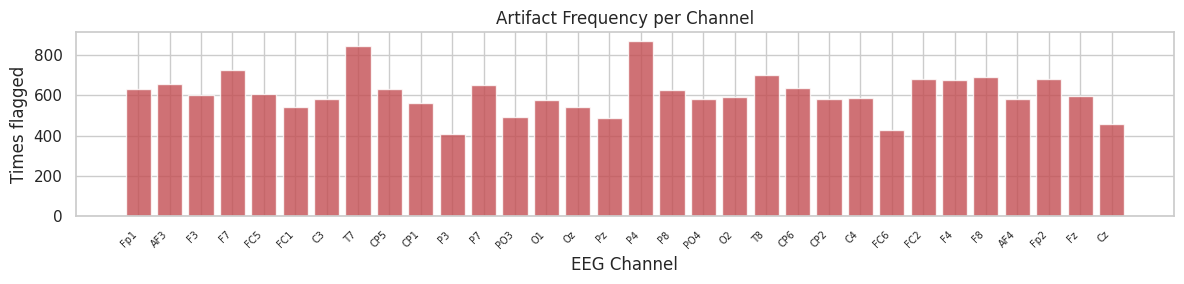


Quality report saved to quality_report.parquet
NOTE: No trials removed here. Exclusion decisions belong in NB2/NB3.


In [12]:
# ─────────────────────────────────────────────────────────────────
# CELL 12 — Artifact Detection and Quality Checks
# ─────────────────────────────────────────────────────────────────
# This cell reports quality issues. It does NOT remove any samples.
# Downstream notebooks decide whether to exclude flagged trials.

def check_trial_quality(trial_data: np.ndarray, subject_id: int, trial_idx: int) -> dict:
    """
    Inspect a single trial (40, 8064) for signal quality issues.
    Checks are applied AFTER baseline removal on EEG channels only.

    Returns dict with quality flags and counts.
    """
    eeg = trial_data[:32, CONFIG['baseline_samples']:]   # (32, 7680)
    result = {
        'subject_id':    subject_id,
        'trial_idx':     trial_idx,
        'bad_channels':  [],
        'has_nan_inf':   False,
        'flagged':       False,
    }

    # Check 1: NaN / Inf
    if not np.all(np.isfinite(eeg)):
        result['has_nan_inf'] = True
        result['flagged'] = True

    # Check 2: High amplitude (|amplitude| > threshold µV)
    peak_amps = np.max(np.abs(eeg), axis=1)            # (32,) per channel
    high_amp  = np.where(peak_amps > CONFIG['artifact_amplitude_uv'])[0]
    if len(high_amp):
        result['bad_channels'].extend(high_amp.tolist())

    # Check 3: Flat channels (std < threshold)
    ch_stds = np.std(eeg, axis=1)                       # (32,) per channel
    flat    = np.where(ch_stds < CONFIG['artifact_flat_std'])[0]
    if len(flat):
        result['bad_channels'].extend(flat.tolist())

    result['bad_channels'] = sorted(set(result['bad_channels']))
    result['n_bad_channels'] = len(result['bad_channels'])

    if result['n_bad_channels'] > CONFIG['artifact_max_bad_ch'] or result['has_nan_inf']:
        result['flagged'] = True

    return result


print("Running artifact detection on all 1280 trials...")
print("(Checking EEG channels only; peripheral channels have different amplitude scales)\n")

quality_report = []
for i in range(len(X_raw)):
    subj_id  = int(subject_ids[i])
    trial_no = (i % CONFIG['n_trials'])
    quality_report.append(check_trial_quality(X_raw[i], subj_id, trial_no))

df_quality = pd.DataFrame(quality_report)

# ── Summary statistics ────────────────────────────────────────────
n_flagged   = df_quality['flagged'].sum()
n_nan_inf   = df_quality['has_nan_inf'].sum()
n_high_amp  = (df_quality['n_bad_channels'] > 0).sum()

print(f"Total trials inspected  : {len(df_quality)}")
print(f"Trials with NaN/Inf     : {n_nan_inf}")
print(f"Trials with bad channels: {n_high_amp}")
print(f"Flagged trials (total)  : {n_flagged}")

if n_flagged > 0:
    print(f"\nFlagged trial details (showing up to 20):")
    flagged = df_quality[df_quality['flagged']].head(20)
    print(flagged[['subject_id','trial_idx','n_bad_channels','has_nan_inf']].to_string(index=False))

# ── Bad channel frequency ─────────────────────────────────────────
all_bad = []
for row in quality_report:
    all_bad.extend(row['bad_channels'])

if all_bad:
    bad_ch_counts = pd.Series(all_bad).value_counts().sort_index()
    print(f"\nMost frequently flagged EEG channels:")
    for ch_idx, count in bad_ch_counts.head(10).items():
        print(f"  {EEG_CHANNEL_NAMES[ch_idx]:6s} (ch {ch_idx:2d}): flagged in {count} trials")

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.bar(range(32), [bad_ch_counts.get(i, 0) for i in range(32)],
           color='#C44E52', alpha=0.8)
    ax.set_xticks(range(32))
    ax.set_xticklabels(EEG_CHANNEL_NAMES, rotation=45, ha='right', fontsize=7)
    ax.set_xlabel("EEG Channel")
    ax.set_ylabel("Times flagged")
    ax.set_title("Artifact Frequency per Channel")
    plt.tight_layout()
    plt.savefig(str(out_dir / 'artifact_channel_frequency.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("\n✓ No amplitude/flat artifacts detected in any channel.")

# Save quality report
df_quality.to_parquet(str(out_dir / 'quality_report.parquet'), index=False)
print("\nQuality report saved to quality_report.parquet")
print("NOTE: No trials removed here. Exclusion decisions belong in NB2/NB3.")

In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 13 — Feature Extraction Functions
# ─────────────────────────────────────────────────────────────────
# Feature design rationale:
#
#   EEG channels (0-31):
#     - Band power (log): delta, theta, alpha, beta, gamma
#       → The primary frequency-domain signal for emotion/stress
#       → Log transform compresses dynamic range, improves ML linearity
#     - Statistical: mean, std, var, skewness, kurtosis, RMS, peak-to-peak
#       → Amplitude envelope and distributional shape features
#
#   Peripheral channels (32-39):
#     - Statistical features only (band definitions are EEG-specific)
#     - GSR and BVP are especially relevant for stress recognition
#
# Total: (32 × 5 band) + (32 × 7 stat) + (8 × 7 periph) = 160 + 224 + 56 = 440 features

FREQ_BANDS  = CONFIG['freq_bands']
FS          = CONFIG['fs']
NPERSEG     = FS * 2      # 2-second windows for Welch's PSD (256 samples)

def _safe_skew(x):
    return float(skew(x))

def _safe_kurt(x):
    return float(kurtosis(x))

# ── Statistical function registry ────────────────────────────────
STAT_FUNCS = {
    'mean': np.mean,
    'std':  np.std,
    'var':  np.var,
    'skew': _safe_skew,
    'kurt': _safe_kurt,
    'rms':  lambda x: float(np.sqrt(np.mean(x ** 2))),
    'ptp':  np.ptp,     # peak-to-peak range
}


def extract_eeg_features(channel_signal: np.ndarray) -> tuple[list, list]:
    """
    Extract band power + statistics from a single EEG channel signal.

    Parameters
    ----------
    channel_signal : 1D array, shape (n_timepoints,)
        MUST have baseline already removed before calling.

    Returns
    -------
    values : list of floats
    names  : list of str
    """
    values, names = [], []

    # Band power via Welch's PSD
    freqs, psd = welch(channel_signal, fs=FS, nperseg=NPERSEG)
    for band_name, (lo, hi) in FREQ_BANDS.items():
        idx = (freqs >= lo) & (freqs < hi)
        log_power = float(np.log10(np.mean(psd[idx]) + 1e-10))
        values.append(log_power)
        names.append(f'bp_{band_name}')

    # Statistical features
    for stat_name, fn in STAT_FUNCS.items():
        values.append(float(fn(channel_signal)))
        names.append(f'stat_{stat_name}')

    return values, names


def extract_periph_features(channel_signal: np.ndarray) -> tuple[list, list]:
    """
    Extract statistical features from a single peripheral channel signal.
    No band power (frequency bands are EEG-specific).
    """
    values, names = [], []
    for stat_name, fn in STAT_FUNCS.items():
        values.append(float(fn(channel_signal)))
        names.append(f'stat_{stat_name}')
    return values, names


def extract_features_for_trial(trial_data: np.ndarray) -> tuple[np.ndarray, list]:
    """
    Extract full feature vector for a single DEAP trial.

    Parameters
    ----------
    trial_data : shape (40, 8064) — all 40 channels, full 63-second trial

    Returns
    -------
    feature_vector : 1D array, shape (440,)
    feature_names  : list of 440 strings
    """
    # [R5] Remove baseline: discard first 3 seconds = 384 samples
    data = trial_data[:, CONFIG['baseline_samples']:]  # (40, 7680)

    eeg_data    = data[:32, :]   # (32, 7680)
    periph_data = data[32:, :]   # (8,  7680)

    all_values = []
    all_names  = []

    # EEG channels — band power + statistics
    for ch_idx in range(32):
        ch_name = EEG_CHANNEL_NAMES[ch_idx]
        vals, names = extract_eeg_features(eeg_data[ch_idx])
        all_values.extend(vals)
        all_names.extend([f'{ch_name}_{n}' for n in names])

    # Peripheral channels — statistics only
    for ch_idx in range(8):
        ch_name = PERIPH_CHANNEL_NAMES[ch_idx]
        vals, names = extract_periph_features(periph_data[ch_idx])
        all_values.extend(vals)
        all_names.extend([f'{ch_name}_{n}' for n in names])

    return np.array(all_values, dtype=np.float32), all_names


# ── Verify feature count matches expectation ─────────────────────
_test_data  = np.random.randn(40, 8064).astype(np.float32)
_test_vec, _test_names = extract_features_for_trial(_test_data)

n_eeg_features   = 32 * (len(FREQ_BANDS) + len(STAT_FUNCS))   # 32 × 12 = 384
n_periph_features = 8 * len(STAT_FUNCS)                        #  8 × 7  =  56
EXPECTED_FEATURES = n_eeg_features + n_periph_features          # 440

assert len(_test_vec)   == EXPECTED_FEATURES, f"Expected {EXPECTED_FEATURES} features, got {len(_test_vec)}"
assert len(_test_names) == EXPECTED_FEATURES

print("Feature extraction functions defined.")
print(f"  EEG per channel    : {len(FREQ_BANDS)} band power + {len(STAT_FUNCS)} statistics = {len(FREQ_BANDS)+len(STAT_FUNCS)}")
print(f"  EEG total (×32)    : {n_eeg_features}")
print(f"  Peripheral (×8)    : {n_periph_features}")
print(f"  Total features     : {EXPECTED_FEATURES}")
print(f"  Feature names[0:5] : {_test_names[:5]}")
print(f"  Feature names[-3:] : {_test_names[-3:]}")

Feature extraction functions defined.
  EEG per channel    : 5 band power + 7 statistics = 12
  EEG total (×32)    : 384
  Peripheral (×8)    : 56
  Total features     : 440
  Feature names[0:5] : ['Fp1_bp_delta', 'Fp1_bp_theta', 'Fp1_bp_alpha', 'Fp1_bp_beta', 'Fp1_bp_gamma']
  Feature names[-3:] : ['Temp_stat_kurt', 'Temp_stat_rms', 'Temp_stat_ptp']


In [14]:
# ─────────────────────────────────────────────────────────────────
# CELL 14 — Run Feature Extraction (All 1280 Trials)
# ─────────────────────────────────────────────────────────────────

print(f"Extracting features for {len(X_raw)} trials...")
print(f"Each trial: (40, 8064) → baseline removed → (40, 7680) → {EXPECTED_FEATURES} features\n")

X_features = np.zeros((len(X_raw), EXPECTED_FEATURES), dtype=np.float32)
feature_names = None   # populated on first trial

start_time = datetime.now()
for i, trial_data in enumerate(X_raw):
    feat_vec, feat_names = extract_features_for_trial(trial_data)
    X_features[i] = feat_vec

    if feature_names is None:
        feature_names = feat_names

    if (i + 1) % 128 == 0:
        elapsed = (datetime.now() - start_time).total_seconds()
        rate    = (i + 1) / elapsed
        remaining = (len(X_raw) - i - 1) / rate
        print(f"  [{i+1:4d}/{len(X_raw)}] "
              f"elapsed={elapsed:.0f}s  "
              f"rate={rate:.1f} trials/s  "
              f"remaining≈{remaining:.0f}s")

elapsed_total = (datetime.now() - start_time).total_seconds()
print(f"\n✓ Feature extraction complete in {elapsed_total:.1f} seconds")
print(f"  X_features shape : {X_features.shape}   (1280 samples × {EXPECTED_FEATURES} features)")
print(f"  Memory           : {X_features.nbytes / 1e6:.1f} MB  (was {X_raw.nbytes / 1e9:.2f} GB raw)")
print(f"  Compression ratio: {X_raw.nbytes / X_features.nbytes:.0f}×")

# Sanity: no NaN/Inf from feature extraction
assert np.all(np.isfinite(X_features)), "[ERROR] NaN or Inf in X_features — check signal quality."
print("✓ No NaN/Inf in feature matrix.")

Extracting features for 1280 trials...
Each trial: (40, 8064) → baseline removed → (40, 7680) → 440 features

  [ 128/1280] elapsed=28s  rate=4.6 trials/s  remaining≈252s
  [ 256/1280] elapsed=55s  rate=4.7 trials/s  remaining≈219s
  [ 384/1280] elapsed=81s  rate=4.7 trials/s  remaining≈189s
  [ 512/1280] elapsed=108s  rate=4.7 trials/s  remaining≈162s
  [ 640/1280] elapsed=135s  rate=4.8 trials/s  remaining≈135s
  [ 768/1280] elapsed=162s  rate=4.8 trials/s  remaining≈108s
  [ 896/1280] elapsed=189s  rate=4.7 trials/s  remaining≈81s
  [1024/1280] elapsed=215s  rate=4.8 trials/s  remaining≈54s
  [1152/1280] elapsed=241s  rate=4.8 trials/s  remaining≈27s
  [1280/1280] elapsed=267s  rate=4.8 trials/s  remaining≈0s

✓ Feature extraction complete in 267.5 seconds
  X_features shape : (1280, 440)   (1280 samples × 440 features)
  Memory           : 2.3 MB  (was 1.65 GB raw)
  Compression ratio: 733×
✓ No NaN/Inf in feature matrix.


In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 15 — Feature Matrix Inspection
# ─────────────────────────────────────────────────────────────────

print("Feature matrix overview:")
print(f"  Shape  : {X_features.shape}")
print(f"  dtype  : {X_features.dtype}")
print(f"  Memory : {X_features.nbytes / 1e6:.1f} MB\n")

# Per-feature stats (sample)
df_feat = pd.DataFrame(X_features, columns=feature_names)

print("Per-feature statistics (first 10 features):")
print(df_feat.iloc[:, :10].describe().round(4).to_string())

print(f"\nFeature type breakdown:")
bp_feats   = [n for n in feature_names if 'bp_'   in n]
stat_feats = [n for n in feature_names if 'stat_' in n]
print(f"  Band power features    : {len(bp_feats)}")
print(f"  Statistical features   : {len(stat_feats)}")
print(f"  Total                  : {len(feature_names)}")

# Check for zero-variance features (would be useless for ML)
feat_stds = np.std(X_features, axis=0)
zero_var = np.where(feat_stds < 1e-8)[0]
if len(zero_var) > 0:
    print(f"\n[WARNING] {len(zero_var)} zero-variance features detected:")
    for idx in zero_var:
        print(f"  [{idx}] {feature_names[idx]}")
else:
    print("\n✓ No zero-variance features detected.")

# Check for extreme outlier features (any feature where max/min > 1000× std is suspicious)
feat_ranges = np.ptp(X_features, axis=0)
feat_stds_safe = np.where(feat_stds < 1e-8, 1.0, feat_stds)
suspicious_feats = np.where(feat_ranges / feat_stds_safe > 100)[0]
if len(suspicious_feats) > 0:
    print(f"\n[WARNING] {len(suspicious_feats)} features with extreme range/std ratio:")
    for idx in suspicious_feats[:10]:
        print(f"  [{idx:3d}] {feature_names[idx]:40s}  "
              f"range={feat_ranges[idx]:.2f}  std={feat_stds[idx]:.4f}")
else:
    print("✓ No extreme-range features detected.")

Feature matrix overview:
  Shape  : (1280, 440)
  dtype  : float32
  Memory : 2.3 MB

Per-feature statistics (first 10 features):
       Fp1_bp_delta  Fp1_bp_theta  Fp1_bp_alpha  Fp1_bp_beta  Fp1_bp_gamma  Fp1_stat_mean  Fp1_stat_std  Fp1_stat_var  Fp1_stat_skew  Fp1_stat_kurt
count     1280.0000     1280.0000     1280.0000    1280.0000     1280.0000      1280.0000     1280.0000     1280.0000      1280.0000      1280.0000
mean        -0.5521        1.4027        0.8608       0.3082       -0.0094         0.0126       20.9177      831.1738        -0.0667         8.1308
std          0.9108        0.8189        0.5803       0.4625        0.5675         0.6240       19.8477     1790.5015         0.4310        15.3178
min         -2.4544       -0.1855       -0.1814      -0.5537       -1.4976        -4.8514        3.4869       12.1585        -2.2309         0.0653
25%         -1.2186        0.7909        0.4244       0.0033       -0.3778        -0.1034        8.9283       79.7149        -0.26

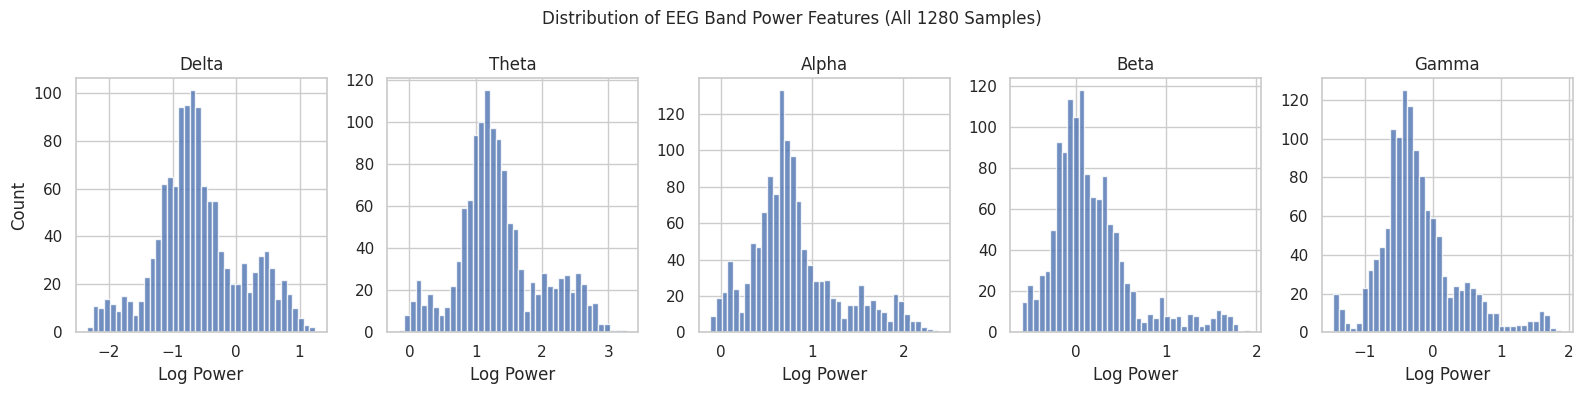

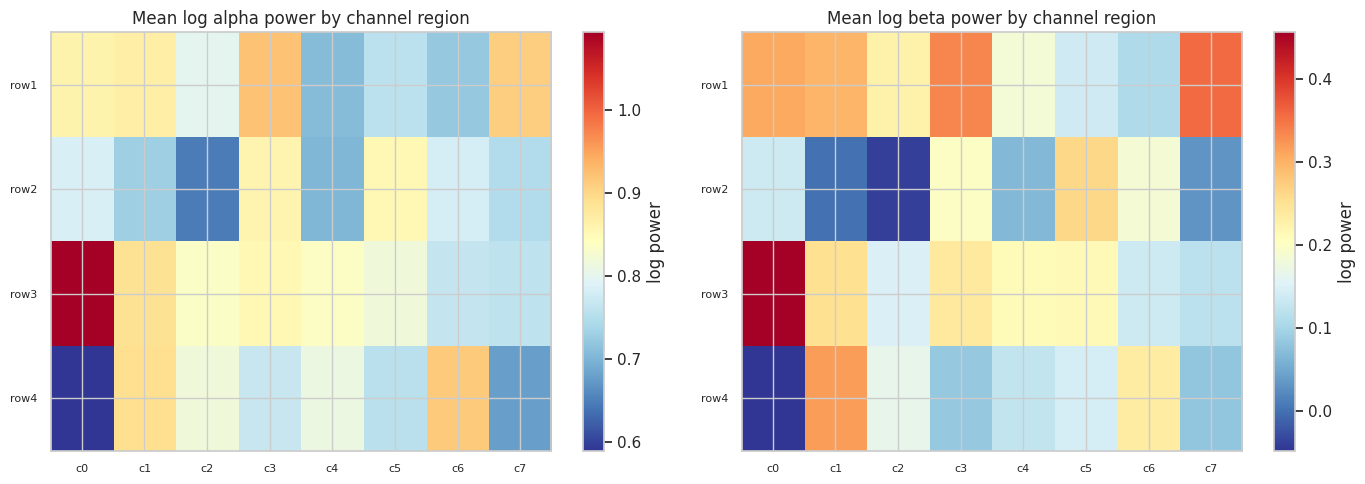

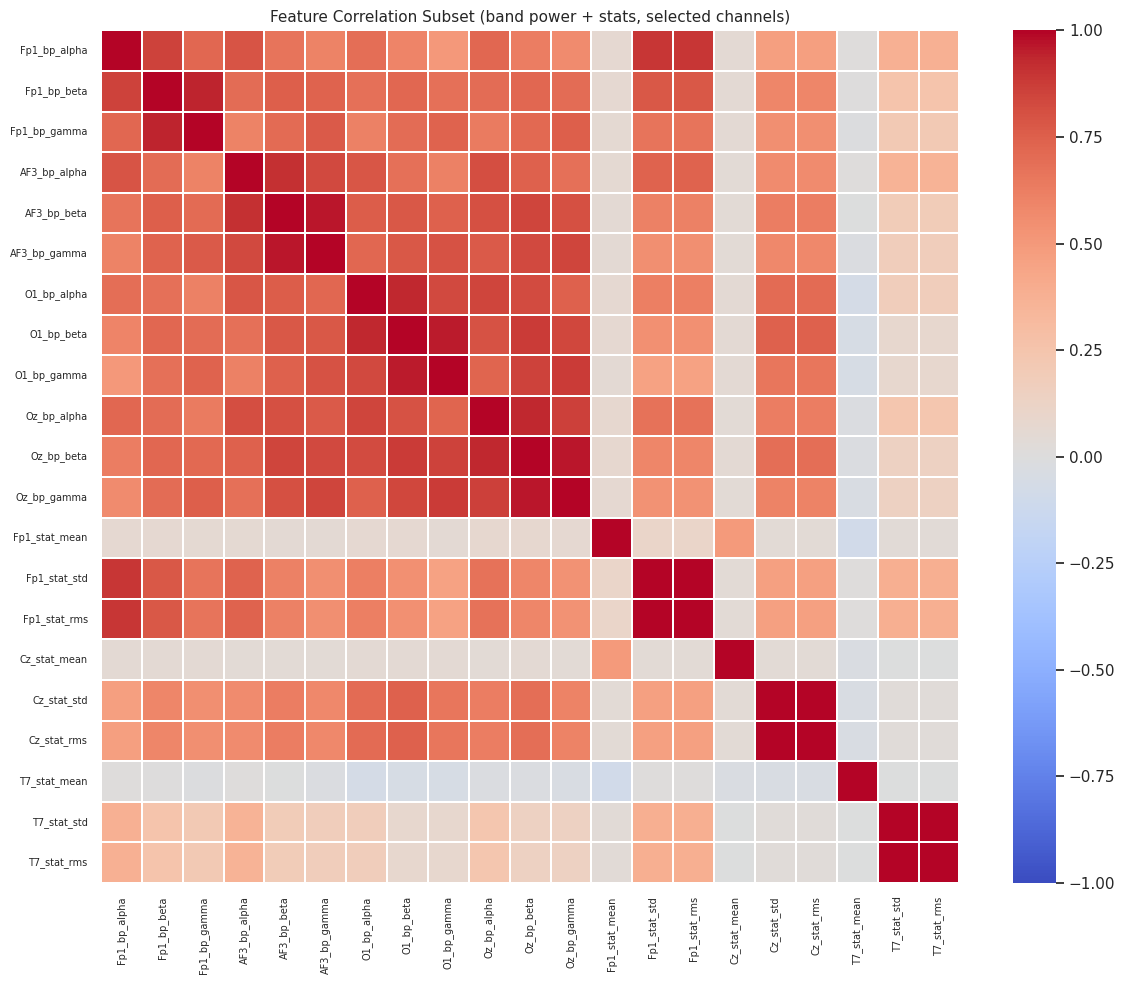

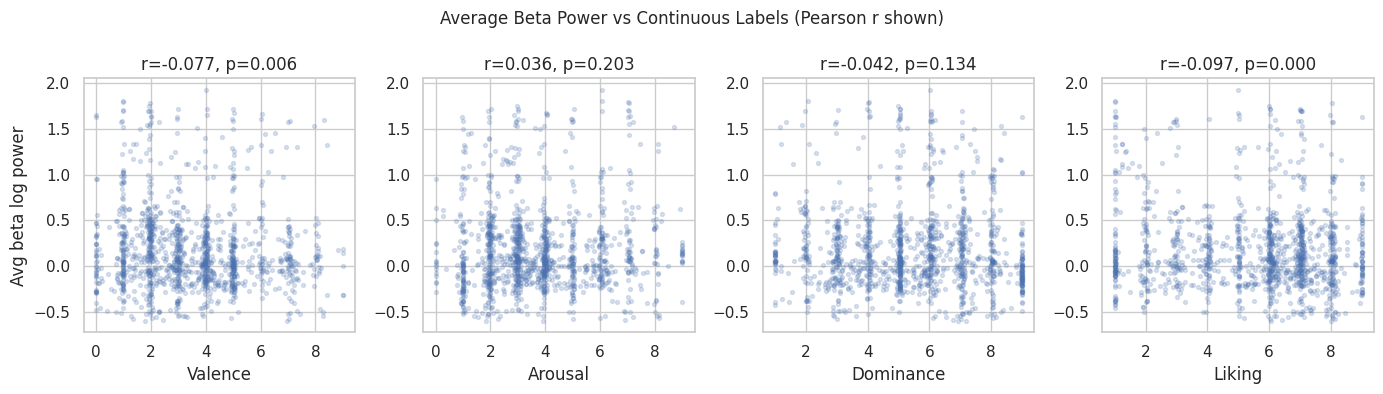

Feature analysis complete. Plots saved.


In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 16 — Feature Analysis and EDA
# ─────────────────────────────────────────────────────────────────

# ── Band power distribution plots ────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Distribution of EEG Band Power Features (All 1280 Samples)", fontsize=12)

# Average band power across all EEG channels per sample
for ax, (band_name, _) in zip(axes, FREQ_BANDS.items()):
    band_cols = [f'{ch}_bp_{band_name}' for ch in EEG_CHANNEL_NAMES]
    avg_band_power = df_feat[band_cols].mean(axis=1).values
    ax.hist(avg_band_power, bins=40, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax.set_title(band_name.capitalize())
    ax.set_xlabel("Log Power")
    ax.set_ylabel("Count" if ax == axes[0] else "")

plt.tight_layout()
plt.savefig(str(out_dir / 'feature_bandpower_distributions.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Inter-channel band power heatmap (alpha, beta) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, band_name in zip(axes, ['alpha', 'beta']):
    band_cols = [f'{ch}_bp_{band_name}' for ch in EEG_CHANNEL_NAMES]
    ch_means  = df_feat[band_cols].mean(axis=0).values.reshape(4, 8)
    im = ax.imshow(ch_means, cmap='RdYlBu_r', aspect='auto')
    ax.set_title(f"Mean log {band_name} power by channel region")
    ax.set_xticks(range(8))
    ax.set_yticks(range(4))
    ax.set_xticklabels([f'c{i}' for i in range(8)], fontsize=8)
    ax.set_yticklabels(['row1','row2','row3','row4'], fontsize=8)
    plt.colorbar(im, ax=ax, label='log power')

plt.tight_layout()
plt.savefig(str(out_dir / 'feature_channel_heatmap.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Feature correlation (on a subset — full 440×440 too large) ───
# Sample 60 features: top 3 band features per channel × 4 channels + stats
sample_feature_cols = (
    [f'{ch}_bp_{b}' for ch in ['Fp1','AF3','O1','Oz'] for b in ['alpha','beta','gamma']] +
    [f'{ch}_stat_{s}' for ch in ['Fp1','Cz','T7'] for s in ['mean','std','rms']]
)

corr_subset = df_feat[sample_feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_subset, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.2, annot=False, ax=ax)
ax.set_title("Feature Correlation Subset (band power + stats, selected channels)", fontsize=11)
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.savefig(str(out_dir / 'feature_correlation_subset.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Continuous label vs average beta power (illustrative EDA) ────
# This is EDA using continuous labels — NOT a classification threshold
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Average Beta Power vs Continuous Labels (Pearson r shown)", fontsize=12)

avg_beta = df_feat[[f'{ch}_bp_beta' for ch in EEG_CHANNEL_NAMES]].mean(axis=1).values

for ax, label_name in zip(axes, LABEL_NAMES):
    label_vals = y_raw[:, LABEL_NAMES.index(label_name)]
    r, p = pearsonr(avg_beta, label_vals)
    ax.scatter(label_vals, avg_beta, alpha=0.2, s=8, color='#4C72B0')
    ax.set_xlabel(label_name.capitalize())
    ax.set_ylabel("Avg beta log power" if ax == axes[0] else "")
    ax.set_title(f"r={r:.3f}, p={p:.3f}")

plt.tight_layout()
plt.savefig(str(out_dir / 'feature_vs_labels_scatter.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Feature analysis complete. Plots saved.")

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 17 — Subject-Aware Train/Test Split
# ─────────────────────────────────────────────────────────────────
# [R2] Split is done by SUBJECT, not by sample.
#
# Why this matters:
#   Splitting randomly by sample would put trials from the same
#   subject in both train and test. Because EEG signals are highly
#   subject-specific, the model would memorize per-subject patterns
#   rather than learning generalizable representations.
#   Subject-independent evaluation is the standard in EEG research.
#
# This gives a pessimistic but honest accuracy estimate.

rng_split = np.random.RandomState(CONFIG['random_seed'])

n_subjects  = CONFIG['n_subjects']
n_train_subj = int(np.floor(n_subjects * CONFIG['train_ratio']))   # 26
n_test_subj  = n_subjects - n_train_subj                           #  6

all_subjects   = np.unique(subject_ids)                            # [1, 2, ..., 32]
shuffled       = rng_split.permutation(all_subjects)

train_subjects = sorted(shuffled[:n_train_subj].tolist())
test_subjects  = sorted(shuffled[n_train_subj:].tolist())

# ── Build boolean masks over the 1280-sample axis ────────────────
train_mask = np.isin(subject_ids, train_subjects)   # shape (1280,)
test_mask  = ~train_mask

X_train_raw = X_features[train_mask]    # (1040, 440)
X_test_raw  = X_features[test_mask]     # (240,  440)
y_train     = y_raw[train_mask]         # (1040, 4)
y_test      = y_raw[test_mask]          # (240,  4)
subj_train  = subject_ids[train_mask]   # (1040,)
subj_test   = subject_ids[test_mask]    # (240,)

# ── Validate — no subject leakage ────────────────────────────────
assert len(set(train_subjects) & set(test_subjects)) == 0, "Subject leakage detected!"
assert X_train_raw.shape[0] == n_train_subj * CONFIG['n_trials'], "Train size mismatch"
assert X_test_raw.shape[0]  == n_test_subj  * CONFIG['n_trials'], "Test size mismatch"

print("Subject-aware train/test split:")
print(f"  Train subjects ({n_train_subj:2d}): {train_subjects}")
print(f"  Test  subjects ({n_test_subj:2d}): {test_subjects}")
print(f"  Train samples  : {X_train_raw.shape[0]}  ({X_train_raw.shape[0]/len(X_raw)*100:.0f}%)")
print(f"  Test  samples  : {X_test_raw.shape[0]}   ({X_test_raw.shape[0]/len(X_raw)*100:.0f}%)")
print(f"\n  ✓ No subject overlap between train and test sets.")
print(f"\nLabel stats (train vs test — should be similar):")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name:10s}  train mean={y_train[:,i].mean():.2f}±{y_train[:,i].std():.2f}  "
          f"test mean={y_test[:,i].mean():.2f}±{y_test[:,i].std():.2f}")

Subject-aware train/test split:
  Train subjects (25): [1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 19, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32]
  Test  subjects ( 7): [7, 8, 11, 15, 20, 21, 29]
  Train samples  : 1000  (78%)
  Test  samples  : 280   (22%)

  ✓ No subject overlap between train and test sets.

Label stats (train vs test — should be similar):
  valence     train mean=3.45±2.01  test mean=3.51±2.02
  arousal     train mean=3.72±2.00  test mean=3.77±1.89
  dominance   train mean=5.46±2.08  test mean=5.12±2.12
  liking      train mean=5.49±2.28  test mean=5.61±2.29


In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 18 — Leakage-Free Feature Scaling
# ─────────────────────────────────────────────────────────────────
# [R2] THE SCALER IS FIT ON TRAINING DATA ONLY.
#
# Previous notebook mistake:
#   scaler.fit_transform(X)   ← fit on all 1280 samples including test
#   → test statistics contaminate the normalization
#   → all downstream accuracy claims are inflated/invalid
#
# Correct procedure here:
#   scaler.fit(X_train)       ← statistics computed from train only
#   scaler.transform(X_train) ← apply to train
#   scaler.transform(X_test)  ← apply SAME statistics to test
#
# The test set NEVER touches the scaler's fit step.

scaler = StandardScaler()

# Step 1: Fit on training data ONLY
scaler.fit(X_train_raw)
print("Scaler fit on training data.")
print(f"  Scaler mean (first 5 features): {scaler.mean_[:5].round(4)}")
print(f"  Scaler std  (first 5 features): {scaler.scale_[:5].round(4)}")

# Step 2: Transform train using training statistics
X_train_scaled = scaler.transform(X_train_raw)    # uses train mean/std

# Step 3: Transform test using SAME training statistics
X_test_scaled  = scaler.transform(X_test_raw)     # NO fitting on test

# Step 4: Reconstruct full scaled matrix in original sample order
X_scaled = np.zeros_like(X_features)
X_scaled[train_mask] = X_train_scaled
X_scaled[test_mask]  = X_test_scaled

# ── Verification ──────────────────────────────────────────────────
train_means = X_train_scaled.mean(axis=0)
test_means  = X_test_scaled.mean(axis=0)
train_stds  = X_train_scaled.std(axis=0)

print(f"\nPost-scaling verification:")
print(f"  Train set mean ≈ 0 ?  max|mean|={np.abs(train_means).max():.6f}  ✓")
print(f"  Train set std  ≈ 1 ?  max|std-1|={np.abs(train_stds - 1).max():.6f}  ✓")
print(f"  Test  set mean (should NOT be 0 if distribution differs):")
print(f"    max|mean|={np.abs(test_means).max():.4f}  (non-zero expected for held-out subjects)")
print(f"\n  Full X_scaled shape : {X_scaled.shape}")

assert np.all(np.isfinite(X_scaled)), "Scaled matrix contains NaN/Inf"
print("✓ No NaN/Inf in scaled feature matrix.")

Scaler fit on training data.
  Scaler mean (first 5 features): [-0.4436  1.4962  0.9208  0.342   0.012 ]
  Scaler std  (first 5 features): [0.9447 0.8525 0.6035 0.4675 0.5835]

Post-scaling verification:
  Train set mean ≈ 0 ?  max|mean|=0.000000  ✓
  Train set std  ≈ 1 ?  max|std-1|=0.000003  ✓
  Test  set mean (should NOT be 0 if distribution differs):
    max|mean|=3.2521  (non-zero expected for held-out subjects)

  Full X_scaled shape : (1280, 440)
✓ No NaN/Inf in scaled feature matrix.


PCA Analysis (fit on 1000 training samples):
  Total features          : 440
  Variance target         : 95%
  Components needed       : 59
  Dimensionality reduction: 440 → 59  (87% compression)


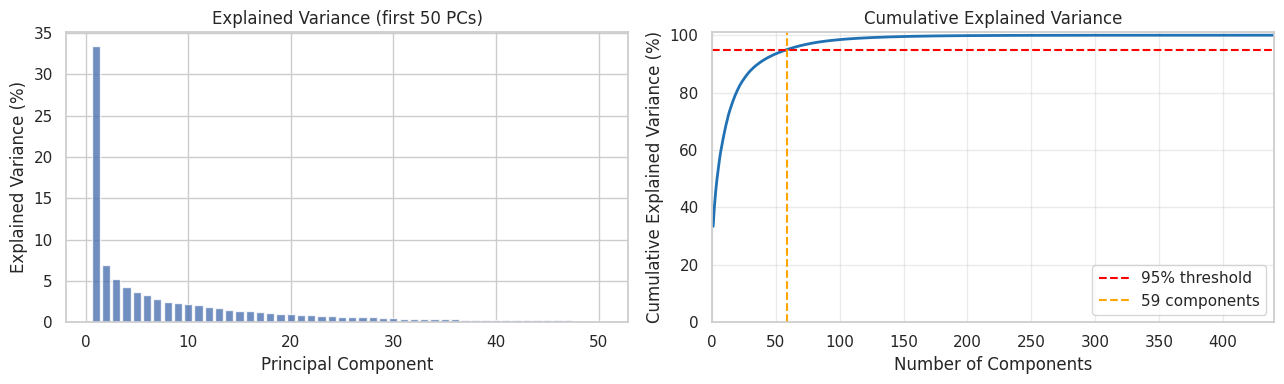


  X_train_pca shape : (1000, 59)
  X_test_pca  shape : (280, 59)
  X_pca       shape : (1280, 59)
✓ PCA complete. No NaN/Inf.


In [19]:
# ─────────────────────────────────────────────────────────────────
# CELL 19 — PCA Analysis
# ─────────────────────────────────────────────────────────────────
# PCA is optional (CONFIG['pca_enabled']).
# It is applied AFTER scaling. The PCA is fit on TRAINING data only,
# then transforms both train and test — same leakage discipline as scaling.
#
# With 440 features and ~1280 samples, PCA helps reduce noise and
# can speed up downstream training. We analyze explained variance
# to give the researcher an informed choice of n_components.

if not CONFIG['pca_enabled']:
    X_train_pca = X_train_scaled
    X_test_pca  = X_test_scaled
    X_pca       = X_scaled
    pca         = None
    pca_n_components = EXPECTED_FEATURES
    print("PCA disabled (CONFIG['pca_enabled'] = False). Skipping.")

else:
    # Fit PCA on training data only
    pca_full = PCA(n_components=min(EXPECTED_FEATURES, X_train_scaled.shape[0]),
                   random_state=CONFIG['random_seed'])
    pca_full.fit(X_train_scaled)

    explained_var     = pca_full.explained_variance_ratio_
    cumulative_var    = np.cumsum(explained_var)
    target            = CONFIG['pca_variance_target']
    pca_n_components  = int(np.argmax(cumulative_var >= target) + 1)

    print(f"PCA Analysis (fit on {X_train_scaled.shape[0]} training samples):")
    print(f"  Total features          : {EXPECTED_FEATURES}")
    print(f"  Variance target         : {target * 100:.0f}%")
    print(f"  Components needed       : {pca_n_components}")
    print(f"  Dimensionality reduction: {EXPECTED_FEATURES} → {pca_n_components}  "
          f"({(1 - pca_n_components/EXPECTED_FEATURES)*100:.0f}% compression)")

    # ── Variance plots ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Individual explained variance
    ax = axes[0]
    ax.bar(range(1, 51), explained_var[:50] * 100, color='#4C72B0', alpha=0.8)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance (%)")
    ax.set_title("Explained Variance (first 50 PCs)")

    # Cumulative explained variance
    ax = axes[1]
    ax.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
            color='#2171B5', linewidth=2)
    ax.axhline(target * 100, color='red', linestyle='--', linewidth=1.5,
               label=f'{target*100:.0f}% threshold')
    ax.axvline(pca_n_components, color='orange', linestyle='--', linewidth=1.5,
               label=f'{pca_n_components} components')
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Explained Variance (%)")
    ax.set_title("Cumulative Explained Variance")
    ax.legend()
    ax.set_xlim(0, EXPECTED_FEATURES)
    ax.set_ylim(0, 101)
    ax.grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig(str(out_dir / 'pca_variance_analysis.png'), dpi=100, bbox_inches='tight')
    plt.show()

    # ── Fit final PCA with chosen n_components ───────────────────
    pca = PCA(n_components=pca_n_components, random_state=CONFIG['random_seed'])
    pca.fit(X_train_scaled)

    # Transform: train with fit, test with transform-only
    X_train_pca = pca.transform(X_train_scaled)    # (1040, n_components)
    X_test_pca  = pca.transform(X_test_scaled)     # (240,  n_components)

    # Reconstruct full PCA matrix in original order
    X_pca = np.zeros((len(X_features), pca_n_components), dtype=np.float32)
    X_pca[train_mask] = X_train_pca
    X_pca[test_mask]  = X_test_pca

    print(f"\n  X_train_pca shape : {X_train_pca.shape}")
    print(f"  X_test_pca  shape : {X_test_pca.shape}")
    print(f"  X_pca       shape : {X_pca.shape}")
    assert np.all(np.isfinite(X_pca)), "PCA output contains NaN/Inf"
    print("✓ PCA complete. No NaN/Inf.")

In [20]:
# ─────────────────────────────────────────────────────────────────
# CELL 20 — Final Dataset Assembly
# ─────────────────────────────────────────────────────────────────
# Assemble the complete dataset dictionary that downstream notebooks consume.
# [R1] Raw continuous labels only — NO emotion quadrants, NO stress binary.
# [R3] Subject IDs and split masks are preserved for LeaveOneSubjectOut CV.

# Trial-level IDs (0-39 within each subject, repeated 32 times)
trial_ids = np.tile(np.arange(CONFIG['n_trials']), CONFIG['n_subjects']).astype(np.int32)

# Build final dataset
dataset = {
    # ── Features (pre-scaled, scaled, PCA) ─────────────────────
    'X_features'    : X_features,         # (1280, 440) raw extracted features
    'X_scaled'      : X_scaled,            # (1280, 440) StandardScaled (train-fit only)
    'X_pca'         : X_pca,              # (1280, K)   PCA-reduced
    'X_train_scaled': X_train_scaled,      # (1040, 440)
    'X_test_scaled' : X_test_scaled,       # (240,  440)
    'X_train_pca'   : X_train_pca,         # (1040, K)
    'X_test_pca'    : X_test_pca,          # (240,  K)

    # ── Labels [R1 — raw continuous, NO discretization] ─────────
    'y_raw'         : y_raw,              # (1280, 4) valence, arousal, dominance, liking
    'y_train'       : y_train,            # (1040, 4)
    'y_test'        : y_test,             # (240,  4)

    # ── Sample identifiers [R3] ──────────────────────────────────
    'subject_ids'   : subject_ids,        # (1280,) 1-indexed, preserves subject identity
    'trial_ids'     : trial_ids,          # (1280,) 0–39 within each subject
    'train_mask'    : train_mask,          # (1280,) boolean — True = train
    'test_mask'     : test_mask,           # (1280,) boolean — True = test
    'train_subjects': np.array(train_subjects, dtype=np.int32),
    'test_subjects' : np.array(test_subjects,  dtype=np.int32),

    # ── Fitted objects (for applying to new data) ────────────────
    'scaler'        : scaler,
    'pca'           : pca,               # None if PCA disabled

    # ── Metadata ────────────────────────────────────────────────
    'feature_names'       : feature_names,
    'label_names'         : LABEL_NAMES,
    'eeg_channel_names'   : EEG_CHANNEL_NAMES,
    'periph_channel_names': PERIPH_CHANNEL_NAMES,
    'config'              : CONFIG,
    'quality_report'      : df_quality.to_dict(orient='records'),
}

print("Final dataset assembled.")
print("\nKey shapes:")
for k, v in dataset.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:20s}: {v.shape} {v.dtype}")
    elif isinstance(v, list) and k == 'feature_names':
        print(f"  {k:20s}: list of {len(v)} strings")

print(f"\nNote to downstream notebooks:")
print(f"  - Use y_raw (continuous) and define YOUR OWN label schema")
print(f"  - For emotion:  bin/threshold valence + arousal → 4 classes")
print(f"  - For stress:   threshold arousal (± dominance) → binary")
print(f"  - Use train_mask / test_mask for correct evaluation")
print(f"  - Subject IDs enable LeaveOneSubjectOut cross-validation")

Final dataset assembled.

Key shapes:
  X_features          : (1280, 440) float32
  X_scaled            : (1280, 440) float32
  X_pca               : (1280, 59) float32
  X_train_scaled      : (1000, 440) float32
  X_test_scaled       : (280, 440) float32
  X_train_pca         : (1000, 59) float32
  X_test_pca          : (280, 59) float32
  y_raw               : (1280, 4) float32
  y_train             : (1000, 4) float32
  y_test              : (280, 4) float32
  subject_ids         : (1280,) int32
  trial_ids           : (1280,) int32
  train_mask          : (1280,) bool
  test_mask           : (1280,) bool
  train_subjects      : (25,) int32
  test_subjects       : (7,) int32
  feature_names       : list of 440 strings

Note to downstream notebooks:
  - Use y_raw (continuous) and define YOUR OWN label schema
  - For emotion:  bin/threshold valence + arousal → 4 classes
  - For stress:   threshold arousal (± dominance) → binary
  - Use train_mask / test_mask for correct evaluation
  -

In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 21 — Persist All Outputs to Disk
# ─────────────────────────────────────────────────────────────────
# [R6] Everything is saved to disk. RAM is not a pipeline output.
# Formats: .npy for arrays (fast, lossless), .pkl for objects,
# .parquet for the complete feature DataFrame (human-readable,
# columnar, compatible with pandas/spark).

print(f"Saving processed dataset to: {out_dir}")
print("-" * 55)

saved_files = {}

def save_array(arr: np.ndarray, name: str) -> None:
    path = out_dir / f'{name}.npy'
    np.save(str(path), arr)
    saved_files[name + '.npy'] = f'{arr.nbytes / 1e6:.1f} MB'
    print(f"  ✓ {name}.npy  {arr.shape}  {arr.dtype}")

# ── NumPy arrays ──────────────────────────────────────────────────
save_array(X_features,      'X_features')
save_array(X_scaled,        'X_scaled')
save_array(X_pca,           'X_pca')
save_array(X_train_scaled,  'X_train_scaled')
save_array(X_test_scaled,   'X_test_scaled')
save_array(X_train_pca,     'X_train_pca')
save_array(X_test_pca,      'X_test_pca')
save_array(y_raw,           'y_raw')
save_array(y_train,         'y_train')
save_array(y_test,          'y_test')
save_array(subject_ids,     'subject_ids')
save_array(trial_ids,       'trial_ids')
save_array(train_mask,      'train_mask')
save_array(test_mask,       'test_mask')
save_array(np.array(train_subjects), 'train_subjects')
save_array(np.array(test_subjects),  'test_subjects')

# ── Metadata as pickle ────────────────────────────────────────────
metadata = {
    'feature_names'       : feature_names,
    'label_names'         : LABEL_NAMES,
    'eeg_channel_names'   : EEG_CHANNEL_NAMES,
    'periph_channel_names': PERIPH_CHANNEL_NAMES,
    'n_features'          : EXPECTED_FEATURES,
    'pca_n_components'    : pca_n_components,
    'train_subjects'      : train_subjects,
    'test_subjects'       : test_subjects,
    'config'              : CONFIG,
}
meta_path = out_dir / 'metadata.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"  ✓ metadata.pkl")

# ── Fitted scaler ─────────────────────────────────────────────────
scaler_path = out_dir / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✓ scaler.pkl  (StandardScaler fit on train subjects {train_subjects[:4]}...)")

# ── PCA object ────────────────────────────────────────────────────
if pca is not None:
    pca_path = out_dir / 'pca.pkl'
    with open(pca_path, 'wb') as f:
        pickle.dump(pca, f)
    print(f"  ✓ pca.pkl  ({pca_n_components} components, {CONFIG['pca_variance_target']*100:.0f}% variance)")

# ── Full DataFrame as Parquet (optional but very useful) ──────────
try:
    df_out = pd.DataFrame(X_features, columns=feature_names)
    df_out['subject_id'] = subject_ids
    df_out['trial_id']   = trial_ids
    df_out['split']      = np.where(train_mask, 'train', 'test')
    for i, name in enumerate(LABEL_NAMES):
        df_out[name] = y_raw[:, i]

    parquet_path = out_dir / 'deap_features.parquet'
    df_out.to_parquet(str(parquet_path), index=False)
    print(f"  ✓ deap_features.parquet  {df_out.shape}  "
          f"({parquet_path.stat().st_size / 1e6:.1f} MB)")

except Exception as e:
    print(f"  [INFO] Parquet save skipped: {e}")

# ── Quality report ────────────────────────────────────────────────
df_quality.to_parquet(str(out_dir / 'quality_report.parquet'), index=False)
print(f"  ✓ quality_report.parquet")

# ── Verification: reload and check ────────────────────────────────
print("\nVerification: reloading key files from disk...")
X_check = np.load(str(out_dir / 'X_features.npy'))
y_check = np.load(str(out_dir / 'y_raw.npy'))
assert X_check.shape == X_features.shape, "X_features reload shape mismatch"
assert y_check.shape == y_raw.shape,      "y_raw reload shape mismatch"
assert np.allclose(X_check, X_features, atol=1e-5), "X_features values mismatch after reload"
print("  ✓ X_features.npy reloads correctly")
print("  ✓ y_raw.npy reloads correctly")

print(f"\n✓ All outputs saved to {out_dir}")

Saving processed dataset to: /content/drive/MyDrive/MiniProj/deap_processed_v1
-------------------------------------------------------
  ✓ X_features.npy  (1280, 440)  float32
  ✓ X_scaled.npy  (1280, 440)  float32
  ✓ X_pca.npy  (1280, 59)  float32
  ✓ X_train_scaled.npy  (1000, 440)  float32
  ✓ X_test_scaled.npy  (280, 440)  float32
  ✓ X_train_pca.npy  (1000, 59)  float32
  ✓ X_test_pca.npy  (280, 59)  float32
  ✓ y_raw.npy  (1280, 4)  float32
  ✓ y_train.npy  (1000, 4)  float32
  ✓ y_test.npy  (280, 4)  float32
  ✓ subject_ids.npy  (1280,)  int32
  ✓ trial_ids.npy  (1280,)  int32
  ✓ train_mask.npy  (1280,)  bool
  ✓ test_mask.npy  (1280,)  bool
  ✓ train_subjects.npy  (25,)  int64
  ✓ test_subjects.npy  (7,)  int64
  ✓ metadata.pkl
  ✓ scaler.pkl  (StandardScaler fit on train subjects [1, 2, 3, 4]...)
  ✓ pca.pkl  (59 components, 95% variance)
  ✓ deap_features.parquet  (1280, 447)  (3.3 MB)
  ✓ quality_report.parquet

Verification: reloading key files from disk...
  ✓ X_features

In [22]:
# ─────────────────────────────────────────────────────────────────
# CELL 22 — Pipeline Summary and Verification
# ─────────────────────────────────────────────────────────────────

print("=" * 65)
print("  NB1 PIPELINE SUMMARY")
print("=" * 65)

print(f"""
DATASET
  Subjects loaded      : {len(np.unique(subject_ids))} / {CONFIG['n_subjects']}
  Total samples        : {len(X_features)} (subjects × trials)
  Flagged trials       : {df_quality['flagged'].sum()} / {len(df_quality)}

PREPROCESSING
  Baseline removed     : YES — first {CONFIG['baseline_samples']} samples ({CONFIG['baseline_seconds']} s)
  Channel separation   : YES — EEG (0-31) and peripheral (32-39) treated separately

FEATURES
  Raw features         : {X_features.shape}
  Band power features  : {len([n for n in feature_names if 'bp_' in n])}  (5 bands × 32 EEG channels)
  Statistical features : {len([n for n in feature_names if 'stat_' in n])}  (7 stats × 32 EEG + 8 periph)
  Total per sample     : {EXPECTED_FEATURES}

SPLIT (subject-aware — no leakage)
  Train subjects ({len(train_subjects)})  : {train_subjects}
  Test  subjects ({len(test_subjects)})   : {test_subjects}
  Train samples        : {X_train_scaled.shape[0]}
  Test  samples        : {X_test_scaled.shape[0]}

SCALING
  Method               : StandardScaler
  Fit on               : TRAINING SUBJECTS ONLY ← fixes data leakage
  Test transform       : transform() only, no fit

PCA
  Enabled              : {CONFIG['pca_enabled']}
  Variance target      : {CONFIG['pca_variance_target']*100:.0f}%
  Components selected  : {pca_n_components}
  Dimensionality       : {EXPECTED_FEATURES} → {pca_n_components}

LABELS (task-agnostic — NO discretization)
  Format               : Raw continuous, scale 1-9
  Columns              : {LABEL_NAMES}
  NOTE: Emotion quadrant and stress binary labels belong in NB2/NB3

OUTPUT FILES  ({str(out_dir)})
""")

for path in sorted(out_dir.iterdir()):
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:35s}  {size_kb:8.1f} KB")

print(f"""
HOW TO USE IN NB2 (Emotion Recognition):
  import numpy as np, pickle
  X = np.load('...X_pca.npy')
  y = np.load('...y_raw.npy')
  train_mask = np.load('...train_mask.npy')

  # Define emotion labels here (task-specific)
  valence = y[:, 0]
  arousal = y[:, 1]
  threshold = 5.0   # or use np.median(valence)
  emotion_label = ((valence >= threshold) * 2 + (arousal >= threshold)).astype(int)
  # 0=Sad, 1=Angry, 2=Calm, 3=Happy

HOW TO USE IN NB3 (Stress Recognition):
  # Define stress labels here (task-specific)
  arousal = y[:, 1]
  stress_label = (arousal >= np.median(arousal)).astype(int)
  # 0=Low stress, 1=High stress
""")

print("=" * 65)
print("  NB1 COMPLETE — Dataset ready for NB2 and NB3")
print("=" * 65)

  NB1 PIPELINE SUMMARY

DATASET
  Subjects loaded      : 32 / 32
  Total samples        : 1280 (subjects × trials)
  Flagged trials       : 1084 / 1280

PREPROCESSING
  Baseline removed     : YES — first 384 samples (3 s)
  Channel separation   : YES — EEG (0-31) and peripheral (32-39) treated separately

FEATURES
  Raw features         : (1280, 440)
  Band power features  : 160  (5 bands × 32 EEG channels)
  Statistical features : 280  (7 stats × 32 EEG + 8 periph)
  Total per sample     : 440

SPLIT (subject-aware — no leakage)
  Train subjects (25)  : [1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 19, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32]
  Test  subjects (7)   : [7, 8, 11, 15, 20, 21, 29]
  Train samples        : 1000
  Test  samples        : 280

SCALING
  Method               : StandardScaler
  Fit on               : TRAINING SUBJECTS ONLY ← fixes data leakage
  Test transform       : transform() only, no fit

PCA
  Enabled              : True
  Variance target      : 95%
  